# Machine Learning detecting financial statement fraud

## Code mô hình

Kích thước dữ liệu: (788, 10)

5 dòng đầu:
  Mã CK  Manipulate  EPS change     Ln(MC)  Leverage  Exchange  Audit  \
0   AAA           1    0.003112  28.763291     23.51         1      1   
1   AAH           0   -1.188119  26.774036      6.34         0      0   
2   AAT           1   -4.576271  26.155877     29.52         1      0   
3   AAV           1    0.475771  26.797743     26.62         1      0   
4   ABC           0    0.544928  26.145206     19.90         0      0   

   Opinion  Beta  Equity change  
0        1  0.95          -2.52  
1        1  1.74          -0.19  
2        0  0.81           5.40  
3        1  0.52          -2.95  
4        1  1.73           2.21  

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 788 entries, 0 to 787
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Mã CK          788 non-null    str    
 1   Manipulate     788 non-null    int64  
 2   EPS change     788 

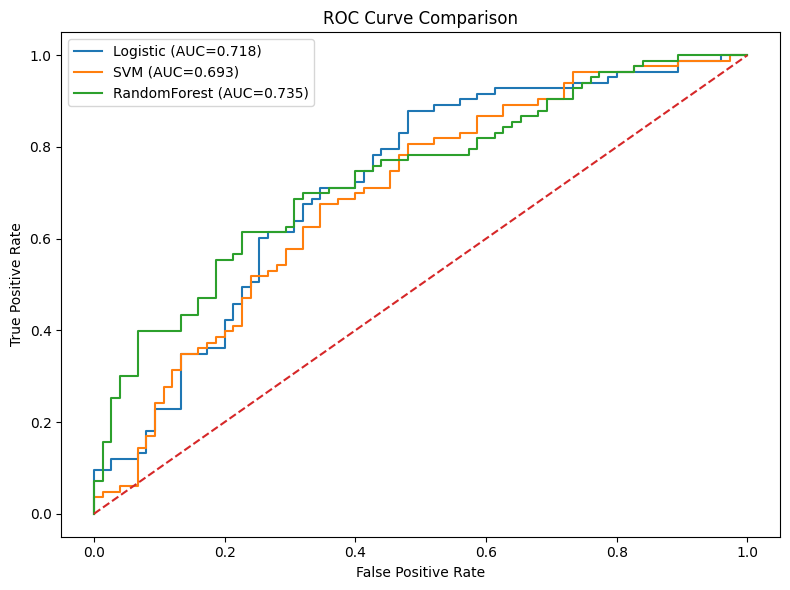

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score
)

# =========================================================
# 1. ĐỌC DỮ LIỆU
# =========================================================
file_path = "Fraud.xlsx"
df = pd.read_excel(file_path)

print("Kích thước dữ liệu:", df.shape)
print("\n5 dòng đầu:")
print(df.head())

print("\nThông tin dữ liệu:")
print(df.info())

print("\nPhân bố biến mục tiêu:")
print(df["Manipulate"].value_counts())
print(df["Manipulate"].value_counts(normalize=True))

# =========================================================
# 2. CHỌN BIẾN
# =========================================================
target_col = "Manipulate"
id_col = "Mã CK"

feature_cols = [col for col in df.columns if col not in [target_col, id_col]]

X = df[feature_cols].copy()
y = df[target_col].copy()

# Nếu sau này có cột object thì giữ phần này
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

# =========================================================
# 3. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, df[id_col],
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

# =========================================================
# 4. PREPROCESS
# =========================================================
numeric_transformer_scale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_noscale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Cho Logistic và SVM
preprocessor_scale = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scale, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Cho Random Forest và KMeans có thể dùng scaler hoặc không
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_noscale, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Riêng KMeans nên scale
preprocessor_cluster = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scale, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# =========================================================
# 5. HÀM ĐÁNH GIÁ
# =========================================================
def evaluate_model(model_name, model, X_test, y_test, threshold=0.5):
    # lấy xác suất lớp 1
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"Threshold: {threshold}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

    result_df = pd.DataFrame({
        "Actual": y_test.values,
        "Pred_Prob": y_prob,
        "Pred_Label": y_pred
    })

    return result_df, {
        "model": model_name,
        "threshold": threshold,
        "accuracy": acc,
        "precision": pre,
        "recall": rec,
        "f1": f1,
        "auc": auc
    }

def find_best_threshold(y_true, y_prob, metric="f1"):
    thresholds = np.arange(0.1, 0.91, 0.01)
    best_threshold = 0.5
    best_score = -1

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true, y_pred, zero_division=0)
        else:
            score = f1_score(y_true, y_pred, zero_division=0)

        if score > best_score:
            best_score = score
            best_threshold = th

    return best_threshold, best_score

# =========================================================
# 6. MODEL 1 - LOGISTIC REGRESSION
# =========================================================
pipe_logit = ImbPipeline(steps=[
    ("preprocess", preprocessor_scale),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_logit = {
    "model__C": [0.01, 0.1, 1, 5, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_logit.fit(X_train, y_train)

print("\nBest Logistic params:", grid_logit.best_params_)
best_logit = grid_logit.best_estimator_

# tìm threshold tốt trên tập train bằng predict xác suất cross-val
logit_train_prob = cross_val_predict(
    best_logit, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

best_th_logit, best_score_logit = find_best_threshold(y_train, logit_train_prob, metric="f1")
print("Best threshold Logistic:", best_th_logit, "| Best F1:", round(best_score_logit, 4))

logit_result_df, logit_metrics = evaluate_model(
    "Logistic Regression", best_logit, X_test, y_test, threshold=best_th_logit
)

# =========================================================
# 7. MODEL 2 - SVM
# =========================================================
pipe_svm = ImbPipeline(steps=[
    ("preprocess", preprocessor_scale),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_svm = {
    "model__C": [0.1, 1, 5, 10],
    "model__kernel": ["rbf", "linear"],
    "model__gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("\nBest SVM params:", grid_svm.best_params_)
best_svm = grid_svm.best_estimator_

svm_train_prob = cross_val_predict(
    best_svm, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

best_th_svm, best_score_svm = find_best_threshold(y_train, svm_train_prob, metric="f1")
print("Best threshold SVM:", best_th_svm, "| Best F1:", round(best_score_svm, 4))

svm_result_df, svm_metrics = evaluate_model(
    "SVM", best_svm, X_test, y_test, threshold=best_th_svm
)

# =========================================================
# 8. MODEL 3 - RANDOM FOREST
# =========================================================
pipe_rf = ImbPipeline(steps=[
    ("preprocess", preprocessor_rf),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid_rf = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("\nBest RandomForest params:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

rf_train_prob = cross_val_predict(
    best_rf, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

best_th_rf, best_score_rf = find_best_threshold(y_train, rf_train_prob, metric="f1")
print("Best threshold RF:", best_th_rf, "| Best F1:", round(best_score_rf, 4))

rf_result_df, rf_metrics = evaluate_model(
    "Random Forest", best_rf, X_test, y_test, threshold=best_th_rf
)


# =========================================================
# 9. SO SÁNH 3 MODEL
# =========================================================
metrics_df = pd.DataFrame([logit_metrics, svm_metrics, rf_metrics])
print("\nBảng so sánh mô hình:")
print(metrics_df.sort_values(by=["f1", "auc"], ascending=False))

best_model_name = metrics_df.sort_values(by=["f1", "auc"], ascending=False).iloc[0]["model"]
print("\nMô hình tốt nhất theo F1 rồi đến AUC:", best_model_name)

# =========================================================
# 10. FEATURE IMPORTANCE (cho Random Forest)
# =========================================================
rf_model = best_rf.named_steps["model"]

# sau preprocess_rf, thứ tự feature gần như là numeric_features + categorical_features
all_processed_features = numeric_features + categorical_features
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_processed_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance - Random Forest:")
print(importance_df)

# =========================================================
# 11. CLUSTERING - KMEANS
# =========================================================
# KMeans không dự đoán xác suất gian lận thật sự
# Ta dùng để phân nhóm doanh nghiệp rồi tính tỷ lệ gian lận trong từng cluster

X_train_cluster = preprocessor_cluster.fit_transform(X_train)
X_test_cluster = preprocessor_cluster.transform(X_test)

# tìm số cluster phù hợp bằng silhouette
best_k = 2
best_sil = -1

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    cluster_labels = km.fit_predict(X_train_cluster)
    sil = silhouette_score(X_train_cluster, cluster_labels)
    print(f"K={k} | Silhouette={sil:.4f}")
    if sil > best_sil:
        best_sil = sil
        best_k = k

print("\nBest K for clustering:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
train_clusters = kmeans.fit_predict(X_train_cluster)
test_clusters = kmeans.predict(X_test_cluster)

# Tính risk score theo cluster trên train
cluster_risk = pd.DataFrame({
    "cluster": train_clusters,
    "fraud": y_train.values
}).groupby("cluster")["fraud"].mean().to_dict()

print("\nFraud rate theo cluster:")
print(cluster_risk)

cluster_test_risk = pd.Series(test_clusters).map(cluster_risk).values

cluster_result_df = pd.DataFrame({
    "Mã CK": id_test.values,
    "Actual": y_test.values,
    "Cluster": test_clusters,
    "Cluster_Risk_Score": cluster_test_risk
})

print("\nKết quả cluster mẫu:")
print(cluster_result_df.head())

# =========================================================
# 12. XUẤT FILE KẾT QUẢ
# =========================================================
test_result = pd.DataFrame({
    "Mã CK": id_test.values,
    "Actual": y_test.values,

    "Logit_Prob": best_logit.predict_proba(X_test)[:, 1],
    "Logit_Pred": (best_logit.predict_proba(X_test)[:, 1] >= best_th_logit).astype(int),

    "SVM_Prob": best_svm.predict_proba(X_test)[:, 1],
    "SVM_Pred": (best_svm.predict_proba(X_test)[:, 1] >= best_th_svm).astype(int),

    "RF_Prob": best_rf.predict_proba(X_test)[:, 1],
    "RF_Pred": (best_rf.predict_proba(X_test)[:, 1] >= best_th_rf).astype(int),

    "Cluster": test_clusters,
    "Cluster_Risk_Score": cluster_test_risk
})

# Xếp hạng rủi ro theo RF
test_result = test_result.sort_values(by="RF_Prob", ascending=False)

test_result.to_excel("fraud_prediction_results.xlsx", index=False)
metrics_df.to_excel("fraud_model_metrics.xlsx", index=False)
importance_df.to_excel("rf_feature_importance.xlsx", index=False)

joblib.dump(best_logit, "best_logit_model.pkl")
joblib.dump(best_svm, "best_svm_model.pkl")
joblib.dump(best_rf, "best_rf_model.pkl")
joblib.dump(kmeans, "kmeans_cluster.pkl")

print("\nĐã lưu:")
print("- fraud_prediction_results.xlsx")
print("- fraud_model_metrics.xlsx")
print("- rf_feature_importance.xlsx")
print("- best_logit_model.pkl")
print("- best_svm_model.pkl")
print("- best_rf_model.pkl")
print("- kmeans_cluster.pkl")

# =========================================================
# 13. VẼ ROC CURVE
# =========================================================
plt.figure(figsize=(8, 6))

for model_name, model in [
    ("Logistic", best_logit),
    ("SVM", best_svm),
    ("RandomForest", best_rf)
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
# =========================================================
# MODEL MỚI - HIST GRADIENT BOOSTING CÓ THRESHOLD TỐI ƯU
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# =========================================================
# 1. Đọc dữ liệu
# =========================================================
file_path = "Fraud.xlsx"
df = pd.read_excel(file_path)

target_col = "Manipulate"
id_col = "Mã CK"

feature_cols = [
    "EPS change",
    "Ln(MC)",
    "Leverage",
    "Exchange",
    "Audit",
    "Opinion",
    "Beta",
    "Equity change"
]

X = df[feature_cols].copy()
y = df[target_col].copy()

# =========================================================
# 2. Train-test split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# 3. Hàm tìm threshold tối ưu
# =========================================================
def find_best_threshold(y_true, y_prob, metric="f1"):
    thresholds = np.arange(0.10, 0.91, 0.01)
    best_threshold = 0.5
    best_score = -1

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true, y_pred, zero_division=0)
        else:
            score = f1_score(y_true, y_pred, zero_division=0)

        if score > best_score:
            best_score = score
            best_threshold = th

    return best_threshold, best_score

# =========================================================
# 4. Khởi tạo model
# =========================================================
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

# =========================================================
# 5. Train model
# =========================================================
hgb_model.fit(X_train, y_train)

# =========================================================
# 6. Tìm threshold tối ưu trên tập train bằng cross_val_predict
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_prob_cv = cross_val_predict(
    hgb_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_th_hgb, best_f1_hgb = find_best_threshold(y_train, train_prob_cv, metric="f1")

print("Best Threshold HGB:", round(best_th_hgb, 2))
print("Best CV-F1 on train:", round(best_f1_hgb, 4))

# =========================================================
# 7. Predict trên test với threshold tối ưu
# =========================================================
y_prob = hgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_th_hgb).astype(int)

# =========================================================
# 8. Evaluate
# =========================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("\n===== HIST GRADIENT BOOSTING (OPTIMAL THRESHOLD) =====")
print("Threshold :", round(best_th_hgb, 2))
print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-score  :", round(f1, 4))
print("AUC       :", round(auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

# =========================================================
# 9. Xuất kết quả dự đoán nếu cần
# =========================================================
hgb_result = pd.DataFrame({
    "Actual": y_test.values,
    "Pred_Prob": y_prob,
    "Pred_Label": y_pred
})

hgb_result.to_excel("hgb_threshold_results.xlsx", index=False)
print("\nĐã lưu: hgb_threshold_results.xlsx")

Best Threshold HGB: 0.36
Best CV-F1 on train: 0.6904

===== HIST GRADIENT BOOSTING (OPTIMAL THRESHOLD) =====
Threshold : 0.36
Accuracy  : 0.6835
Precision : 0.6435
Recall    : 0.8916
F1-score  : 0.7475
AUC       : 0.7613

Confusion Matrix:
[[34 41]
 [ 9 74]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7907    0.4533    0.5763        75
           1     0.6435    0.8916    0.7475        83

    accuracy                         0.6835       158
   macro avg     0.7171    0.6724    0.6619       158
weighted avg     0.7134    0.6835    0.6662       158


Đã lưu: hgb_threshold_results.xlsx


## Vẽ ROC Curve 4 mô hình

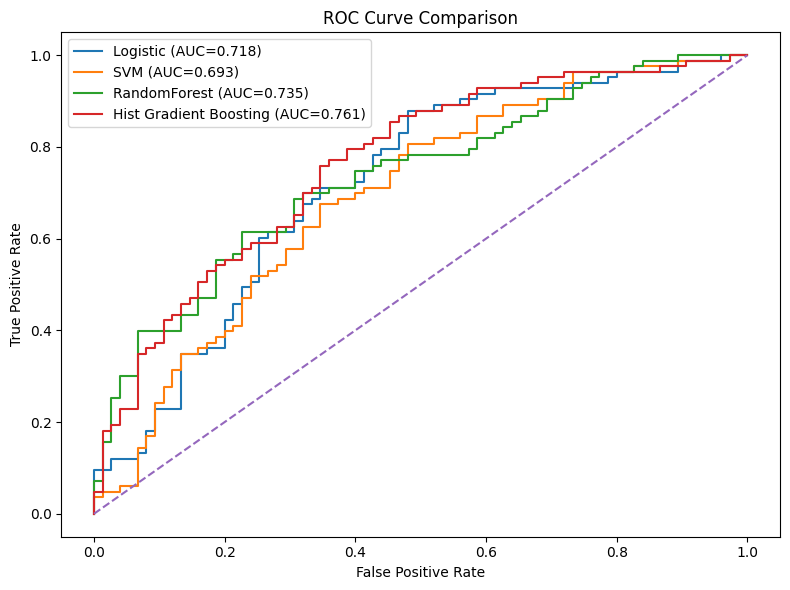

In [3]:
# 13. VẼ ROC CURVE
# =========================================================
plt.figure(figsize=(8, 6))

for model_name, model in [
    ("Logistic", best_logit),
    ("SVM", best_svm),
    ("RandomForest", best_rf),
    ("Hist Gradient Boosting", hgb_model)
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Cross validation kiểm tra overfitting

In [4]:
from sklearn.model_selection import cross_validate

# =========================================================
# CROSS VALIDATION
# =========================================================
print("\n" + "="*60)
print("CROSS VALIDATION (5-FOLD)")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "Logistic Regression": best_logit,
    "SVM": best_svm,
    "Random Forest": best_rf
}

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    result = {
        "Model": name,

        "Train Accuracy": scores["train_accuracy"].mean(),
        "Test Accuracy": scores["test_accuracy"].mean(),

        "Train Precision": scores["train_precision"].mean(),
        "Test Precision": scores["test_precision"].mean(),

        "Train Recall": scores["train_recall"].mean(),
        "Test Recall": scores["test_recall"].mean(),

        "Train F1": scores["train_f1"].mean(),
        "Test F1": scores["test_f1"].mean(),

        "Train AUC": scores["train_roc_auc"].mean(),
        "Test AUC": scores["test_roc_auc"].mean(),

        # độ ổn định
        "F1 Std": scores["test_f1"].std(),
        "AUC Std": scores["test_roc_auc"].std()
    }

    cv_results.append(result)

cv_df = pd.DataFrame(cv_results).round(4)

print("\nKết quả Cross Validation:")
print(cv_df.sort_values(by="Test F1", ascending=False))

# Xuất file
cv_df.to_excel("cross_validation_results.xlsx", index=False)
print("\nĐã lưu: cross_validation_results.xlsx")


CROSS VALIDATION (5-FOLD)

Kết quả Cross Validation:
                 Model  Train Accuracy  Test Accuracy  Train Precision  \
2        Random Forest          0.9254         0.6603           0.9426   
1                  SVM          0.6750         0.6540           0.6968   
0  Logistic Regression          0.6647         0.6508           0.7029   

   Test Precision  Train Recall  Test Recall  Train F1  Test F1  Train AUC  \
2          0.6773        0.9142       0.6835    0.9281   0.6798     0.9848   
1          0.6728        0.6784       0.6686    0.6871   0.6703     0.7370   
0          0.6889        0.6303       0.6145    0.6645   0.6489     0.7127   

   Test AUC  F1 Std  AUC Std  
2    0.7080  0.0561   0.0597  
1    0.7077  0.0415   0.0441  
0    0.6996  0.0468   0.0428  

Đã lưu: cross_validation_results.xlsx


In [5]:
sample = X_test.iloc[0:1]

prob = best_logit.predict_proba(sample)[0][1]
print("Xác suất gian lận:", prob)

Xác suất gian lận: 0.42646166084225384


In [6]:
model = best_logit.named_steps["model"]

coefficients = model.coef_[0]
features = numeric_features + categorical_features

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

         Feature  Coefficient
2       Leverage     0.524113
6           Beta     0.363567
7  Equity change     0.063221
0     EPS change    -0.088366
3       Exchange    -0.089080
4          Audit    -0.154349
1         Ln(MC)    -0.186014
5        Opinion    -0.276317


## Ma trận tương quan

In [7]:
import pandas as pd

# Chọn các biến số (bỏ Mã CK)
df_corr = df.drop(columns=["Mã CK"])

# Tính ma trận tương quan
corr_matrix = df_corr.corr()

print(corr_matrix)

               Manipulate  EPS change    Ln(MC)  Leverage  Exchange     Audit  \
Manipulate       1.000000   -0.034028 -0.136544  0.256256 -0.080486 -0.130804   
EPS change      -0.034028    1.000000  0.049627  0.012592  0.042386  0.021715   
Ln(MC)          -0.136544    0.049627  1.000000 -0.083853  0.169389  0.472560   
Leverage         0.256256    0.012592 -0.083853  1.000000 -0.046558 -0.022224   
Exchange        -0.080486    0.042386  0.169389 -0.046558  1.000000  0.142909   
Audit           -0.130804    0.021715  0.472560 -0.022224  0.142909  1.000000   
Opinion         -0.187532    0.116305  0.201881 -0.031364  0.316114  0.199403   
Beta             0.113252    0.040878  0.302413  0.022261 -0.053349  0.128277   
Equity change   -0.038361    0.017641  0.148813 -0.070295  0.158938  0.039291   

                Opinion      Beta  Equity change  
Manipulate    -0.187532  0.113252      -0.038361  
EPS change     0.116305  0.040878       0.017641  
Ln(MC)         0.201881  0.302413   

## Thống kê mô tả

In [8]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_excel("Fraud.xlsx")

# Chọn các biến cần thống kê mô tả
cols = [
    "Manipulate",
    "EPS change",
    "Ln(MC)",
    "Leverage",
    "Exchange",
    "Audit",
    "Opinion",
    "Beta",
    "Equity change"
]

desc = df[cols].describe().T
desc["median"] = df[cols].median()
desc["skew"] = df[cols].skew()
desc["kurtosis"] = df[cols].kurt()

# Sắp xếp lại cột cho đẹp
desc = desc[[
    "count", "mean", "std", "min", "25%", "50%", "75%", "max", "median", "skew", "kurtosis"
]]

print(desc)

               count       mean        std         min        25%        50%  \
Manipulate     788.0   0.526650   0.499606    0.000000   0.000000   1.000000   
EPS change     788.0  -0.160448  21.450270 -516.666667  -0.288973   0.080525   
Ln(MC)         788.0  27.334075   1.887150   22.534828  25.943845  27.130842   
Leverage       788.0  25.166434  17.397534    0.050000  11.450000  22.700000   
Exchange       788.0   0.631980   0.482573    0.000000   0.000000   1.000000   
Audit          788.0   0.246193   0.431066    0.000000   0.000000   0.000000   
Opinion        788.0   0.865482   0.341424    0.000000   1.000000   1.000000   
Beta           788.0   0.573439   0.563283   -1.370000   0.180000   0.500000   
Equity change  788.0   7.035381  52.607626 -316.200000   0.687500   4.365000   

                     75%         max     median       skew    kurtosis  
Manipulate      1.000000    1.000000   1.000000  -0.106954   -1.993627  
EPS change      0.551365   80.647059   0.080525 -19.1

## Cluster

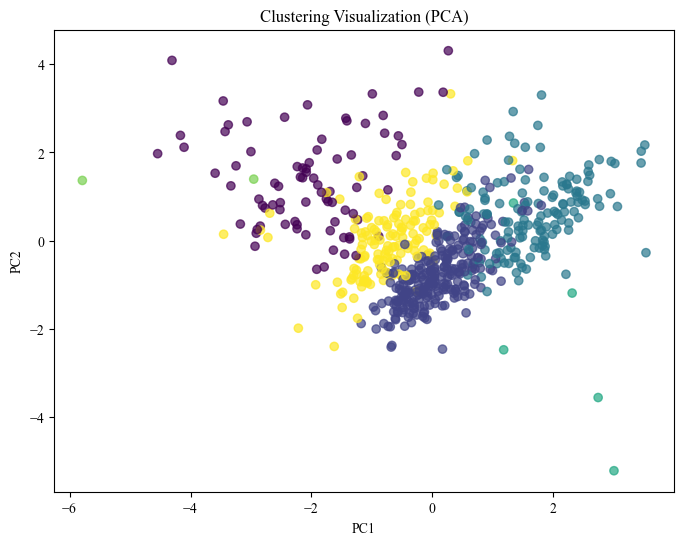

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 👉 Set font Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# giảm chiều về 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_cluster)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=train_clusters,
    alpha=0.7
)

plt.title("Clustering Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [10]:
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate

# =========================================================
# HÀM ĐÁNH GIÁ OVERFIT
# =========================================================
def evaluate_overfit(model_name, model, X_train, y_train, X_test, y_test):
    # ----- Train -----
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    train_acc = accuracy_score(y_train, y_train_pred)
    train_pre = precision_score(y_train, y_train_pred, zero_division=0)
    train_rec = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    train_auc = roc_auc_score(y_train, y_train_prob)

    # ----- Test -----
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    test_acc = accuracy_score(y_test, y_test_pred)
    test_pre = precision_score(y_test, y_test_pred, zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_auc = roc_auc_score(y_test, y_test_prob)

    # ----- Gaps -----
    acc_gap = train_acc - test_acc
    f1_gap = train_f1 - test_f1
    auc_gap = train_auc - test_auc

    # Quy tắc kết luận đơn giản
    if f1_gap > 0.15 or auc_gap > 0.15:
        overfit_level = "Overfit rõ rệt"
    elif f1_gap > 0.07 or auc_gap > 0.07:
        overfit_level = "Overfit nhẹ đến trung bình"
    else:
        overfit_level = "Khá ổn định"

    return {
        "Model": model_name,

        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Accuracy Gap": round(acc_gap, 4),

        "Train Precision": round(train_pre, 4),
        "Test Precision": round(test_pre, 4),

        "Train Recall": round(train_rec, 4),
        "Test Recall": round(test_rec, 4),

        "Train F1": round(train_f1, 4),
        "Test F1": round(test_f1, 4),
        "F1 Gap": round(f1_gap, 4),

        "Train AUC": round(train_auc, 4),
        "Test AUC": round(test_auc, 4),
        "AUC Gap": round(auc_gap, 4),

        "Kết luận": overfit_level
    }

# =========================================================
# CHẠY CHO CÁC MODEL
# =========================================================
overfit_results = []

overfit_results.append(
    evaluate_overfit("Logistic Regression", best_logit, X_train, y_train, X_test, y_test)
)

overfit_results.append(
    evaluate_overfit("SVM", best_svm, X_train, y_train, X_test, y_test)
)

overfit_results.append(
    evaluate_overfit("Random Forest", best_rf, X_train, y_train, X_test, y_test)
)

# Nếu bạn có model HGB:
overfit_results.append(
    evaluate_overfit("HistGradientBoosting", hgb_model, X_train, y_train, X_test, y_test)
)

overfit_df = pd.DataFrame(overfit_results)
print(overfit_df)

# Xuất file nếu cần
overfit_df.to_excel("overfit_test_results.xlsx", index=False)
print("\nĐã lưu: overfit_test_results.xlsx")

                  Model  Train Accuracy  Test Accuracy  Accuracy Gap  \
0   Logistic Regression          0.6587         0.6519        0.0068   
1                   SVM          0.6619         0.6392        0.0227   
2         Random Forest          0.9254         0.6899        0.2355   
3  HistGradientBoosting          0.7651         0.6709        0.0942   

   Train Precision  Test Precision  Train Recall  Test Recall  Train F1  \
0           0.6970          0.6892        0.6235       0.6145    0.6582   
1           0.6877          0.6757        0.6566       0.6024    0.6718   
2           0.9495          0.7125        0.9066       0.6867    0.9276   
3           0.7968          0.7013        0.7440       0.6506    0.7695   

   Test F1  F1 Gap  Train AUC  Test AUC  AUC Gap                    Kết luận  
0   0.6497  0.0085     0.7124    0.7182  -0.0058                 Khá ổn định  
1   0.6369  0.0349     0.7330    0.6935   0.0395                 Khá ổn định  
2   0.6994  0.2282     0.9

## kiểm tra proxy
Kiểm tra độ nhất quán giữa F-score, M-score, Z-score
Kiểm tra mức độ liên hệ giữa từng proxy với biến phụ thuộc Manipulate

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, spearmanr
from sklearn.metrics import cohen_kappa_score

# =========================
# 1. Đọc dữ liệu
# =========================
file_path = r"C:\Users\manhphi2811\OneDrive - National Economics University\KLTN\Manipulate.xlsx"   # đổi lại nếu cần
df = pd.read_excel(file_path)

# Chuẩn hóa tên cột phòng trường hợp có khoảng trắng thừa
df.columns = df.columns.str.strip()

# Chọn các cột cần dùng
target_col = "Manipulate"
proxy_cols = ["F score", "M score", "Z score"]

# Kiểm tra dữ liệu thiếu
print("=== KIỂM TRA DỮ LIỆU THIẾU ===")
print(df[[target_col] + proxy_cols].isnull().sum())
print()

# =========================
# 2. Thống kê mô tả cơ bản
# =========================
print("=== PHÂN BỐ BIẾN PHỤ THUỘC ===")
print(df[target_col].value_counts(dropna=False))
print()
print("Tỷ lệ Manipulate = 1:", round(df[target_col].mean() * 100, 2), "%")
print()

print("=== PHÂN BỐ CÁC PROXY ===")
for col in proxy_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))
    print("Tỷ lệ = 1:", round(df[col].mean() * 100, 2), "%")

print("\n" + "="*60 + "\n")

# =========================
# 3. Kiểm tra độ nhất quán giữa các proxy
# =========================

# 3.1 Ma trận tương quan Spearman
print("=== MA TRẬN TƯƠNG QUAN SPEARMAN GIỮA CÁC PROXY ===")
corr_matrix = df[proxy_cols].corr(method="spearman")
print(corr_matrix)
print()

# 3.2 Cohen's Kappa giữa từng cặp proxy
print("=== COHEN'S KAPPA GIỮA TỪNG CẶP PROXY ===")
for i in range(len(proxy_cols)):
    for j in range(i+1, len(proxy_cols)):
        col1, col2 = proxy_cols[i], proxy_cols[j]
        kappa = cohen_kappa_score(df[col1], df[col2])
        print(f"{col1} vs {col2}: {kappa:.4f}")
print()

# 3.3 Bảng chéo + kiểm định Chi-square giữa các proxy
print("=== KIỂM ĐỊNH CHI-SQUARE GIỮA TỪNG CẶP PROXY ===")
for i in range(len(proxy_cols)):
    for j in range(i+1, len(proxy_cols)):
        col1, col2 = proxy_cols[i], proxy_cols[j]
        crosstab = pd.crosstab(df[col1], df[col2])
        chi2, p, dof, expected = chi2_contingency(crosstab)
        
        print(f"\n--- {col1} vs {col2} ---")
        print("Bảng chéo:")
        print(crosstab)
        print(f"Chi-square = {chi2:.4f}")
        print(f"p-value    = {p:.4f}")
        print(f"df         = {dof}")

print("\n" + "="*60 + "\n")

# =========================
# 4. Kiểm tra quan hệ giữa từng proxy và biến Manipulate
# =========================

print("=== QUAN HỆ GIỮA TỪNG PROXY VÀ BIẾN PHỤ THUỘC Manipulate ===")
for col in proxy_cols:
    print(f"\n--- {col} vs {target_col} ---")
    
    # Bảng chéo
    crosstab = pd.crosstab(df[col], df[target_col])
    print("Bảng chéo:")
    print(crosstab)
    
    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(crosstab)
    print(f"Chi-square = {chi2:.4f}")
    print(f"p-value    = {p:.4f}")
    print(f"df         = {dof}")
    
    # Spearman correlation
    corr, corr_p = spearmanr(df[col], df[target_col])
    print(f"Spearman rho = {corr:.4f}")
    print(f"Spearman p   = {corr_p:.4f}")

print("\n" + "="*60 + "\n")

# =========================
# 5. Kiểm tra mức độ đồng thuận giữa 3 proxy
# =========================

# Số proxy gắn nhãn gian lận cho mỗi doanh nghiệp
df["proxy_sum"] = df[proxy_cols].sum(axis=1)

print("=== MỨC ĐỘ ĐỒNG THUẬN GIỮA 3 PROXY ===")
print(df["proxy_sum"].value_counts().sort_index())
print()

agreement_table = df["proxy_sum"].value_counts(normalize=True).sort_index() * 100
print("Tỷ lệ phần trăm theo số lượng proxy cùng gán nhãn:")
for k, v in agreement_table.items():
    print(f"{int(k)} proxy đồng ý: {v:.2f}%")

print()

# Tạo các nhóm đồng thuận
df["at_least_1"] = (df["proxy_sum"] >= 1).astype(int)
df["at_least_2"] = (df["proxy_sum"] >= 2).astype(int)
df["all_3"] = (df["proxy_sum"] == 3).astype(int)

print("Tỷ lệ ít nhất 1 proxy gắn nhãn gian lận:", round(df["at_least_1"].mean() * 100, 2), "%")
print("Tỷ lệ ít nhất 2 proxy cùng gắn nhãn gian lận:", round(df["at_least_2"].mean() * 100, 2), "%")
print("Tỷ lệ cả 3 proxy cùng gắn nhãn gian lận:", round(df["all_3"].mean() * 100, 2), "%")
print()

# =========================
# 6. Xuất kết quả ra Excel để dễ xem
# =========================
with pd.ExcelWriter("kiem_dinh_proxy.xlsx", engine="openpyxl") as writer:
    corr_matrix.to_excel(writer, sheet_name="Spearman_Corr")
    
    df[[target_col] + proxy_cols + ["proxy_sum", "at_least_1", "at_least_2", "all_3"]].to_excel(
        writer, sheet_name="Proxy_Data", index=False
    )

print("Đã chạy xong. File kết quả lưu tại: kiem_dinh_proxy.xlsx")

=== KIỂM TRA DỮ LIỆU THIẾU ===
Manipulate    0
F score       0
M score       0
Z score       0
dtype: int64

=== PHÂN BỐ BIẾN PHỤ THUỘC ===
Manipulate
1    415
0    373
Name: count, dtype: int64

Tỷ lệ Manipulate = 1: 52.66 %

=== PHÂN BỐ CÁC PROXY ===

F score:
F score
0    738
1     50
Name: count, dtype: int64
Tỷ lệ = 1: 6.35 %

M score:
M score
0    624
1    164
Name: count, dtype: int64
Tỷ lệ = 1: 20.81 %

Z score:
Z score
0    494
1    294
Name: count, dtype: int64
Tỷ lệ = 1: 37.31 %


=== MA TRẬN TƯƠNG QUAN SPEARMAN GIỮA CÁC PROXY ===
          F score   M score   Z score
F score  1.000000  0.020439  0.046772
M score  0.020439  1.000000  0.037568
Z score  0.046772  0.037568  1.000000

=== COHEN'S KAPPA GIỮA TỪNG CẶP PROXY ===
F score vs M score: 0.0165
F score vs Z score: 0.0283
M score vs Z score: 0.0346

=== KIỂM ĐỊNH CHI-SQUARE GIỮA TỪNG CẶP PROXY ===

--- F score vs M score ---
Bảng chéo:
M score    0    1
F score          
0        586  152
1         38   12
Chi-square = 0.

## Giải thích mô hình và hàm ý kiểm toán

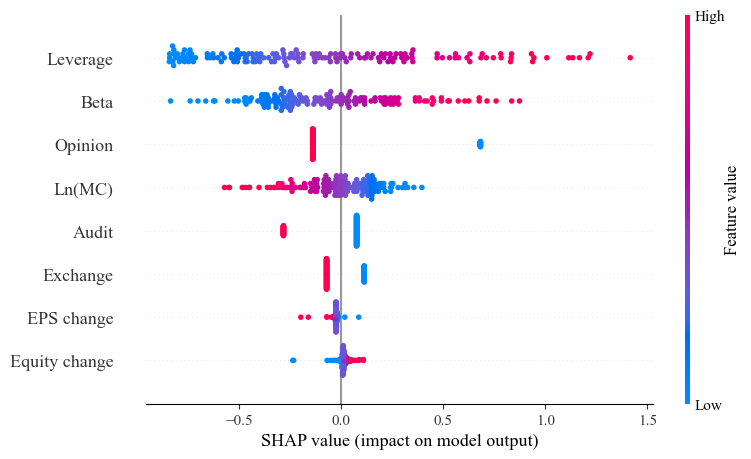

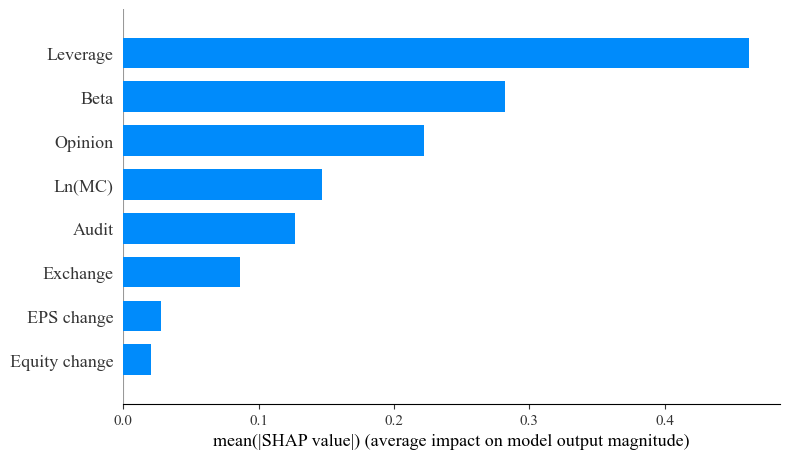

Top biến quan trọng - Logistic Regression
         Feature  Mean(|SHAP|)
2       Leverage      0.462061
6           Beta      0.282078
5        Opinion      0.221933
1         Ln(MC)      0.147063
4          Audit      0.126563
3       Exchange      0.085944
0     EPS change      0.028088
7  Equity change      0.020452

Đã lưu: logit_shap_importance.xlsx


In [13]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# SHAP - LOGISTIC REGRESSION
# ==============================

# Lấy preprocessor và model từ pipeline
logit_preprocess = best_logit.named_steps["preprocess"]
logit_model = best_logit.named_steps["model"]

# Transform dữ liệu
X_train_logit = logit_preprocess.transform(X_train)
X_test_logit = logit_preprocess.transform(X_test)

# Nếu output là sparse matrix thì chuyển sang dense
if hasattr(X_train_logit, "toarray"):
    X_train_logit = X_train_logit.toarray()
if hasattr(X_test_logit, "toarray"):
    X_test_logit = X_test_logit.toarray()

# Tên biến sau preprocess
logit_feature_names = numeric_features + categorical_features

# Chuyển sang DataFrame cho dễ đọc
X_train_logit_df = pd.DataFrame(X_train_logit, columns=logit_feature_names)
X_test_logit_df = pd.DataFrame(X_test_logit, columns=logit_feature_names)

# Tạo explainer
explainer_logit = shap.LinearExplainer(logit_model, X_train_logit_df)
shap_values_logit = explainer_logit(X_test_logit_df)

# ==============================
# 1. Summary plot
# ==============================
shap.summary_plot(shap_values_logit.values, X_test_logit_df, feature_names=logit_feature_names)

# ==============================
# 2. Bar plot
# ==============================
shap.summary_plot(shap_values_logit.values, X_test_logit_df, feature_names=logit_feature_names, plot_type="bar")

# ==============================
# 3. Bảng SHAP importance
# ==============================
logit_shap_importance = pd.DataFrame({
    "Feature": logit_feature_names,
    "Mean(|SHAP|)": np.abs(shap_values_logit.values).mean(axis=0)
}).sort_values(by="Mean(|SHAP|)", ascending=False)

print("Top biến quan trọng - Logistic Regression")
print(logit_shap_importance)

logit_shap_importance.to_excel("logit_shap_importance.xlsx", index=False)
print("\nĐã lưu: logit_shap_importance.xlsx")

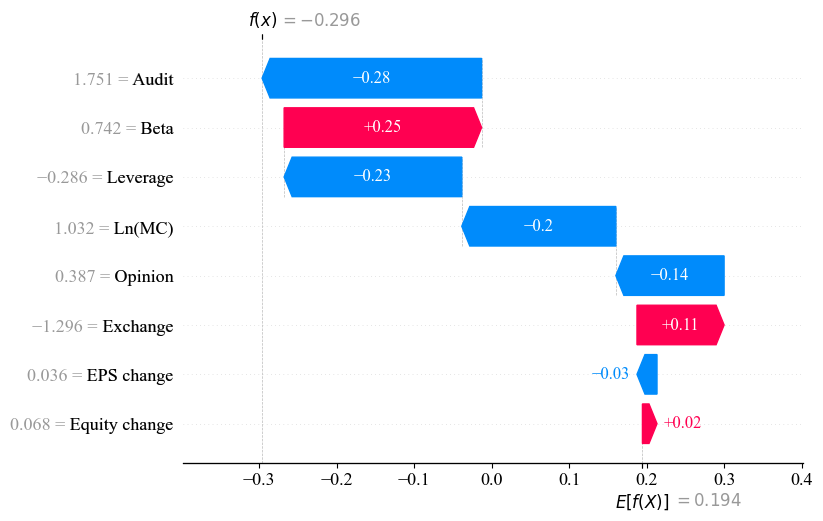

In [14]:
i = 0
shap.plots.waterfall(shap_values_logit[i])

In [15]:
# giả sử có danh sách mã công ty tương ứng test set
test_result = X_test.copy()
test_result["Actual"] = y_test.values
test_result["Pred_Prob"] = best_logit.predict_proba(X_test)[:, 1]
test_result["Pred_Label"] = (test_result["Pred_Prob"] >= 0.5).astype(int)

print(test_result.head())

     EPS change     Ln(MC)  Leverage  Exchange  Audit  Opinion  Beta  \
195    0.470721  29.250033     20.22         0      1        1  1.01   
421    0.049853  27.484098     38.30         0      0        1  1.67   
680   -0.001890  26.342551     33.87         1      0        1  0.21   
262    0.346815  25.416913     23.10         0      0        0  0.50   
104    0.625990  25.749300     27.57         1      0        1  0.15   

     Equity change  Actual  Pred_Prob  Pred_Label  
195          11.45       0   0.426462           0  
421           0.16       0   0.767961           1  
680         -11.40       0   0.511920           1  
262           5.76       0   0.735070           1  
104           6.75       0   0.473727           0  


ExactExplainer explainer: 159it [00:30,  5.12it/s]                         


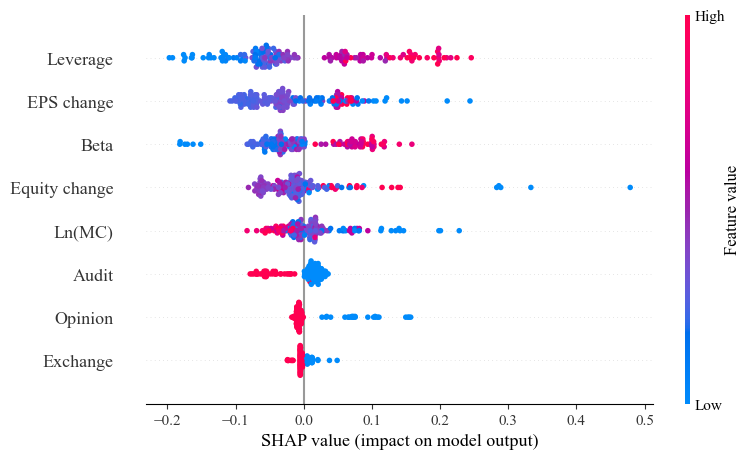

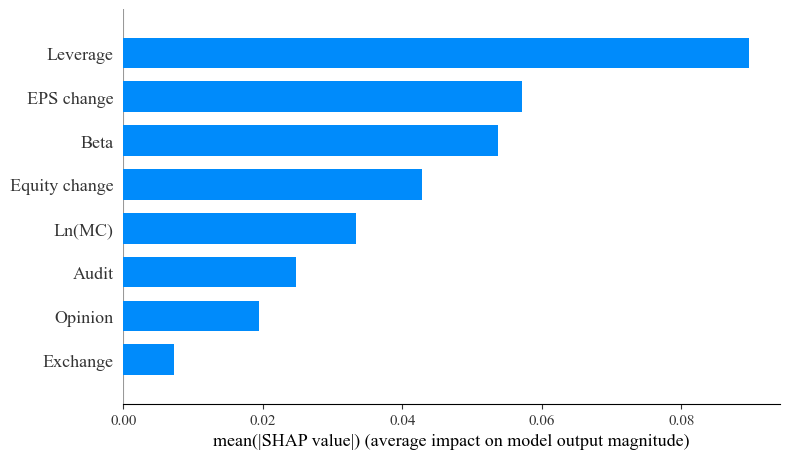

Top biến quan trọng - HistGradientBoosting
         Feature  Mean(|SHAP|)
2       Leverage      0.089673
0     EPS change      0.057174
6           Beta      0.053705
7  Equity change      0.042879
1         Ln(MC)      0.033404
4          Audit      0.024729
5        Opinion      0.019450
3       Exchange      0.007231

Đã lưu: hgb_shap_importance.xlsx


In [16]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# SHAP - HISTGRADIENTBOOSTING
# ==============================

# Lấy mẫu nền để tăng tốc
background_hgb = shap.sample(X_train, 100, random_state=42)

# Explainer
explainer_hgb = shap.Explainer(hgb_model.predict_proba, background_hgb)

# Chỉ lấy một phần test cho nhanh, có thể đổi thành toàn bộ X_test nếu muốn
X_test_hgb_sample = X_test.copy()
shap_values_hgb = explainer_hgb(X_test_hgb_sample)

# Với bài toán nhị phân, class 1 là xác suất gian lận
# shap_values_hgb.values có shape: (n_samples, n_features, n_classes)

# ==============================
# 1. Summary plot cho class 1
# ==============================
shap.summary_plot(
    shap_values_hgb.values[:, :, 1],
    X_test_hgb_sample,
    feature_names=X_test_hgb_sample.columns
)

# ==============================
# 2. Bar plot cho class 1
# ==============================
shap.summary_plot(
    shap_values_hgb.values[:, :, 1],
    X_test_hgb_sample,
    feature_names=X_test_hgb_sample.columns,
    plot_type="bar"
)

# ==============================
# 3. Bảng SHAP importance
# ==============================
hgb_shap_importance = pd.DataFrame({
    "Feature": X_test_hgb_sample.columns,
    "Mean(|SHAP|)": np.abs(shap_values_hgb.values[:, :, 1]).mean(axis=0)
}).sort_values(by="Mean(|SHAP|)", ascending=False)

print("Top biến quan trọng - HistGradientBoosting")
print(hgb_shap_importance)

hgb_shap_importance.to_excel("hgb_shap_importance.xlsx", index=False)
print("\nĐã lưu: hgb_shap_importance.xlsx")